<a href="https://colab.research.google.com/github/siddhipawar645/Python_Task27/blob/main/Task27.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Q1

In [ ]:
from sklearn.datasets import make_moons
X,y_true=make_moons(n_samples=500,noise=0.05,random_state=42)
df=pd.DataFrame(X,columns=["Feature 1","Feature 2"])

In [ ]:
df.head(10)

,Feature 1,Feature 2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185
5,1.254903,-0.483435
6,1.053851,-0.442690
7,0.031380,1.053012
8,0.620545,0.713096
9,1.787657,-0.142959


In [ ]:
df.shape

(500, 2)

Q2

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)
df.head()

,Feature 1,Feature 2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


Q3

In [20]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=2)
df["kmeans_cluster"]=kmeans.fit_predict(X_scaled)
df.head()

,Feature 1,Feature 2,kmeans_cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0


<Axes: xlabel='Feature 1', ylabel='Feature 2'>

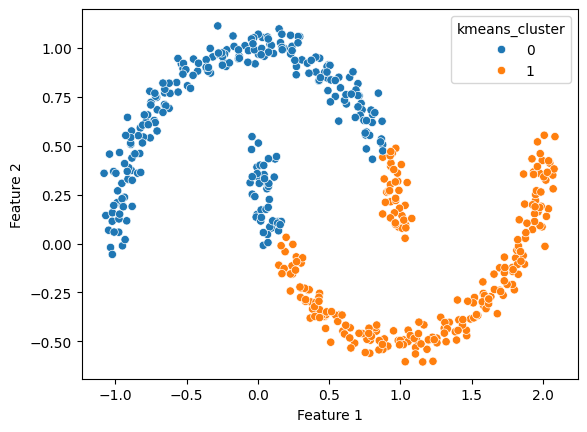

In [21]:
sns.scatterplot(x=df["Feature 1"],y=df["Feature 2"],hue=df["kmeans_cluster"])

Q4

In [29]:
from sklearn.cluster import DBSCAN
model_DBSCAN=DBSCAN(eps=0.3,min_samples=5)
df["dbscan_cluster"]=model_DBSCAN.fit_predict(X_scaled)
df.head()

,Feature 1,Feature 2,kmeans_cluster,DBSCAN_cluster,dbscan_cluster
0,0.830586,-0.447733,1,0,0
1,0.701678,0.816918,0,1,1
2,1.022080,-0.492571,1,0,0
3,-0.316765,0.953438,0,1,1
4,0.293226,1.057185,0,1,1


<Axes: xlabel='Feature 1', ylabel='Feature 2'>

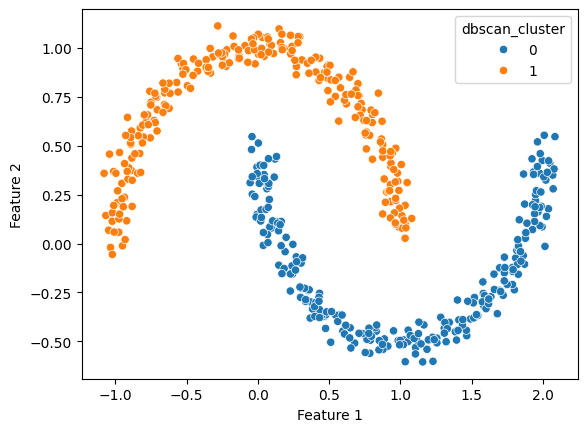

In [30]:
sns.scatterplot(x=df["Feature 1"],y=df["Feature 2"],hue=df["dbscan_cluster"])

Q5

In [31]:
# Observations:
print("1. KMeans assumes spherical clusters, so it does not separate the moon-shaped data correctly.")
print("2. Some data points are assigned to the wrong cluster in KMeans.")
print("3. DBSCAN correctly identifies the two moon-shaped clusters using density.")
print("4. DBSCAN detects noise points and labels them as -1.")
print("5. KMeans assigns every point to a cluster, while DBSCAN can leave noise points unclustered.")
# Conclusion:
print("\nConclusion:")
print("DBSCAN performs better than KMeans for non-linear datasets because it handles non-spherical clusters and noise more effectively.")

1. KMeans assumes spherical clusters, so it does not separate the moon-shaped data correctly.
2. Some data points are assigned to the wrong cluster in KMeans.
3. DBSCAN correctly identifies the two moon-shaped clusters using density.
4. DBSCAN detects noise points and labels them as -1.
5. KMeans assigns every point to a cluster, while DBSCAN can leave noise points unclustered.

Conclusion:
DBSCAN performs better than KMeans for non-linear datasets because it handles non-spherical clusters and noise more effectively.


Q6

In [35]:
eps_values=[0.2, 0.3, 0.4, 0.5]
results=[]
for eps in eps_values:
    dbscan=DBSCAN(eps=eps,min_samples=5)
    labels=dbscan.fit_predict(X_scaled)
n_clusters=len(set(labels))-(1 if -1 in labels else 0)
n_noise=list(labels).count(-1)
results.append([eps, n_clusters, n_noise])
result_df=pd.DataFrame(results, columns=["eps", "Number of Clusters", "Number of Noise Points"])
print(result_df)

   eps  Number of Clusters  Number of Noise Points
0  0.5                   2                       0


Q7

In [40]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
X, y_true=make_blobs(n_samples=500,n_features=6,centers=4,cluster_std=1.5,random_state=42)
df=pd.DataFrame(X,columns=[f"Feature{i+1}"for i in range(6)])
df.head()

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6
0,-7.430902,6.549456,2.166481,3.468039,-10.240054,8.934439
1,-0.746455,-5.467049,4.342113,-6.163268,-4.821673,-3.392003
2,-2.337856,9.239739,4.094461,1.887751,-6.417925,-9.445362
3,-7.659628,7.961709,0.571836,4.089885,-9.593714,7.660650
4,-10.169566,6.667335,3.105872,3.602202,-6.997864,8.798743


In [41]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)

Q8

In [44]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
pca_df=pd.DataFrame(X_pca,columns=["PC1","PC2"])
pca_df["Cluster"]=y_true
pca_df.head()

[0.64327878 0.21039738]


In [46]:
print(pca.explained_variance_ratio_)
pca.explained_variance_ratio_.sum()

[0.64327878 0.21039738]


np.float64(0.853676159895889)

Q9

Text(0, 0.5, 'Principal Component 2(PC2)')

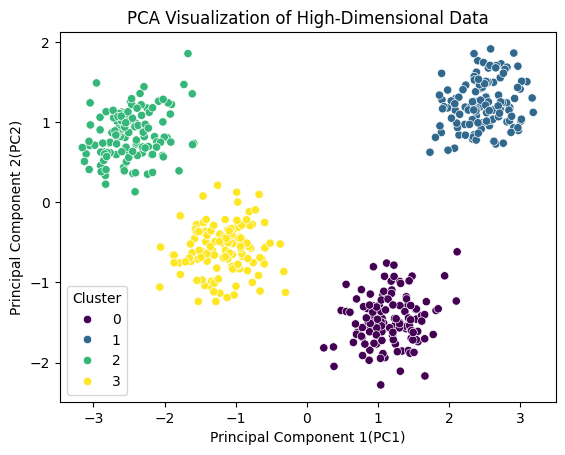

In [50]:
sns.scatterplot(data=pca_df,x="PC1",y="PC2",hue="Cluster",palette="viridis")
plt.title("PCA Visualization of High-Dimensional Data")
plt.xlabel("Principal Component 1(PC1)")
plt.ylabel("Principal Component 2(PC2)")


In [51]:
print("Observation:")
print("The explained variance ratio indicates the amount of information retained by PC1 and PC2.")
print("Higher explained variance means less information is lost after PCA.")
print("If the total explained variance is high, the 2D PCA plot represents the original dataset well.")

Observation:
The explained variance ratio indicates the amount of information retained by PC1 and PC2.
Higher explained variance means less information is lost after PCA.
If the total explained variance is high, the 2D PCA plot represents the original dataset well.


Q10

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Data scaled successfully.


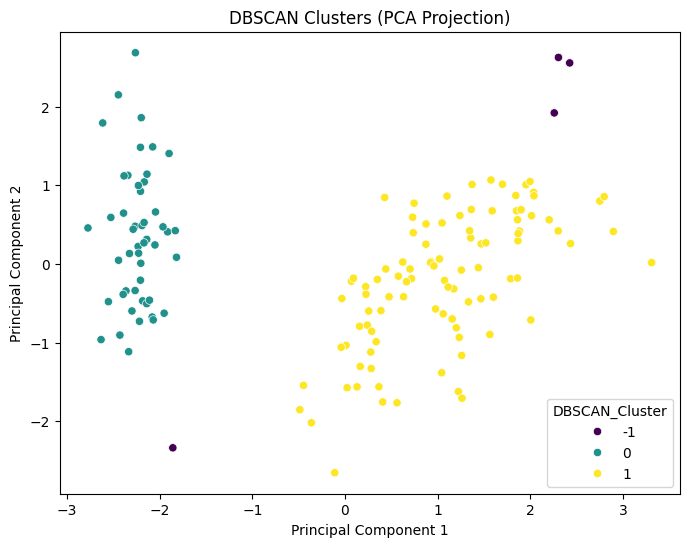


Explained Variance Ratio:
[0.72962445 0.22850762]


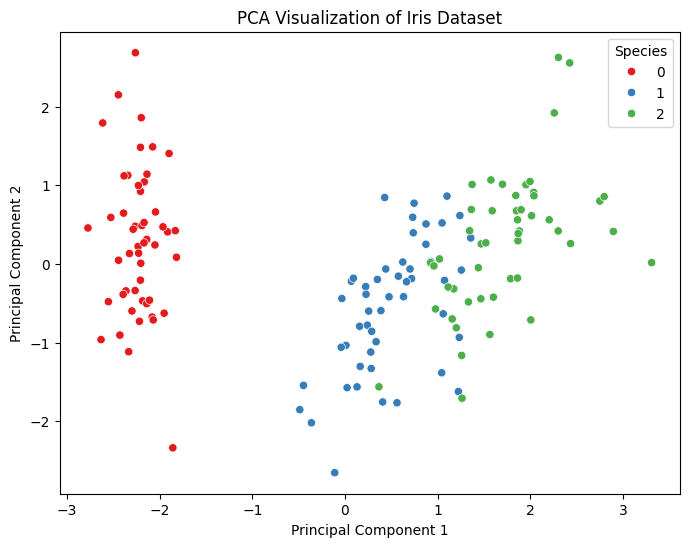


Observation:
1. The Iris dataset was scaled before clustering.
2. DBSCAN grouped similar samples based on density.
3. PCA reduced the dataset from 4 features to 2 principal components.
4. The PCA plot shows how well the samples are separated in 2D.
5. The explained variance ratio indicates how much information is retained after dimensionality reduction.


In [60]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
print("First 5 rows:")
print(df.head())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print("\nData scaled successfully.")
dbscan = DBSCAN(eps=0.8, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)
df["DBSCAN_Cluster"] = db_labels
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["DBSCAN_Cluster"] = db_labels
plt.figure(figsize=(8,6))
sns.scatterplot( data=pca_df,x="PC1",y="PC2",hue="DBSCAN_Cluster",palette="viridis"
)
plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)
pca_df["Species"] = iris.target
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df,x="PC1",y="PC2",hue="Species",palette="Set1"
)
plt.title("PCA Visualization of Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Observation
print("\nObservation:")
print("1. The Iris dataset was scaled before clustering.")
print("2. DBSCAN grouped similar samples based on density.")
print("3. PCA reduced the dataset from 4 features to 2 principal components.")
print("4. The PCA plot shows how well the samples are separated in 2D.")
print("5. The explained variance ratio indicates how much information is retained after dimensionality reduction.")